In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

load data

In [2]:
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

In [3]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_dataset.shape


(768, 9)

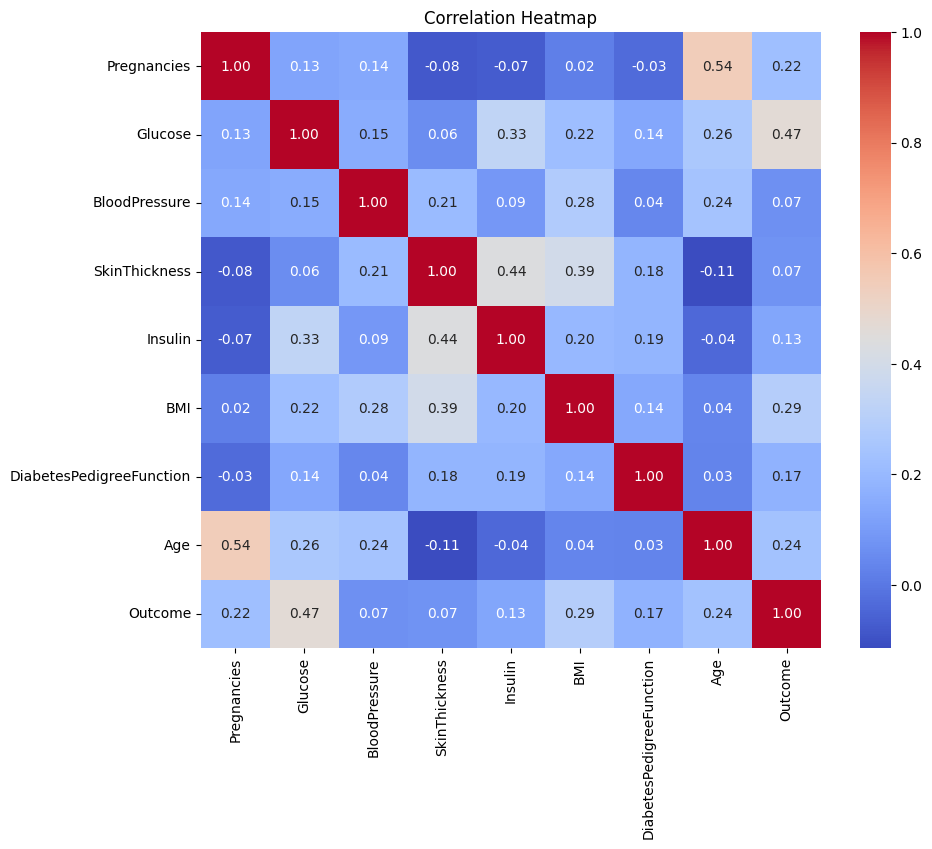

In [6]:
#Correlation Heatmap

#This helps you see which features are most related to the target variable (Outcome).

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(diabetes_dataset.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

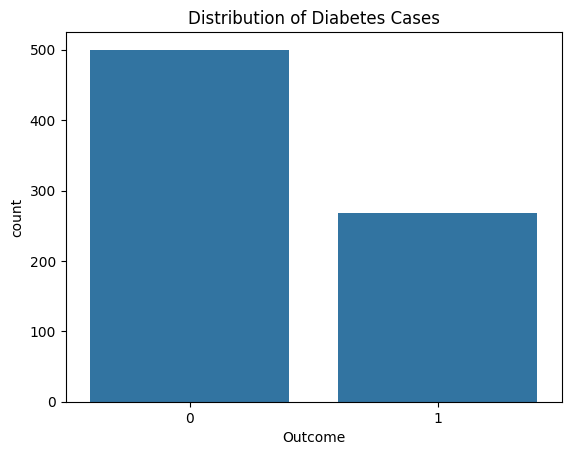

In [7]:
#Diabetes vs Non-Diabetes Count
sns.countplot(x='Outcome', data=diabetes_dataset)

plt.title('Distribution of Diabetes Cases')
plt.show()

Interpretation:
**bold text**
0 = Non-diabetic
1 = Diabetic

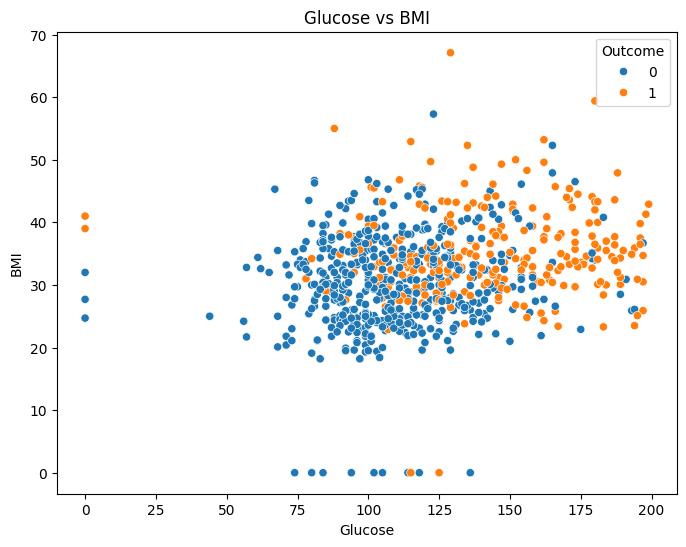

In [8]:
#Glucose vs BMI
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=diabetes_dataset
)

plt.title('Glucose vs BMI')
plt.show()

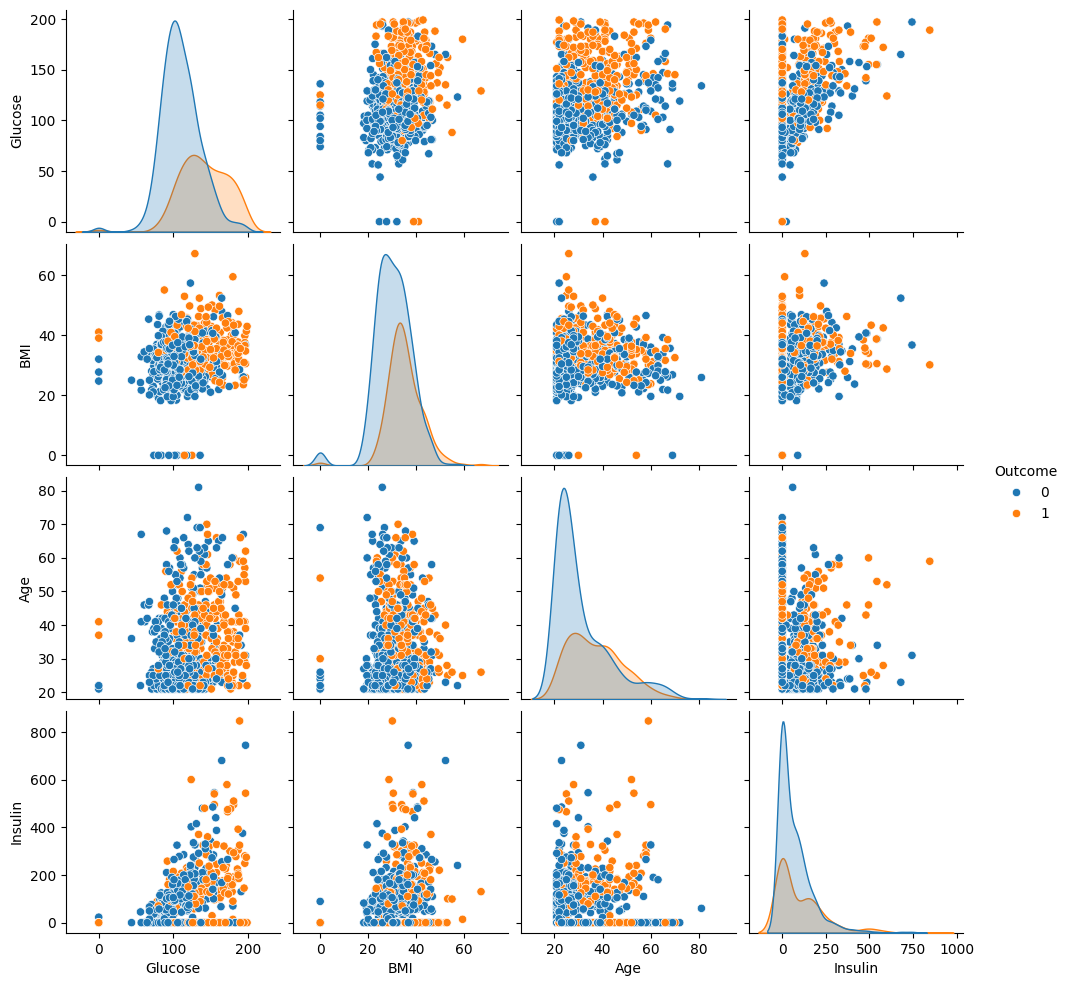

In [9]:
#A pairplot is an automatic visualization tool that shows the distribution of each feature and the relationship between every pair of features in a single figure.
sns.pairplot(
    diabetes_dataset,
    hue='Outcome',
    vars=['Glucose', 'BMI', 'Age', 'Insulin']
)

plt.show()

In [10]:
## separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [11]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [12]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data Standardization

In [13]:
scaler = StandardScaler()
scaler.fit(X)
standardized_data = scaler.transform(X)
print(standardized_data)


[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [14]:
X = standardized_data

Train Test Split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [16]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Train the model

In [17]:
classifier = svm.SVC(kernel='linear')

In [18]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

Model Evaluation

In [20]:
# accuracy score on the test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [21]:
print(test_data_accuracy)

0.7727272727272727


Making a predective System

After training the Support Vector Machine (SVM) model, we can use it to predict whether a new patient is diabetic or non-diabetic.

First, we provide the patient's medical information as input features. Since the model was trained on standardized data, the new input must also be standardized using the same scaler.

The trained model then analyzes the input data and generates a prediction:

0 → The person is not diabetic.
1 → The person is diabetic.

This predictive system demonstrates how machine learning models can be used to make predictions on unseen data and support medical decision-making.

In [24]:
input_data = (5,160,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.3429808   1.22388954  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
